# IMPLEMENTATION OF A RECURRENT NEURAL NETWORK (RNN) FOR TEXT GENERATION

**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072  


## Task A: Dataset Preparation


In [1]:
# Install/import required libraries
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
# Download the Tiny Shakespeare dataset directly from code
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
dataset_path = tf.keras.utils.get_file("shakespeare.txt", dataset_url)

with open(dataset_path, "r", encoding="utf-8") as file:
    text = file.read()

print("Dataset downloaded successfully.")
print("Number of characters:", len(text))
print("\nSample text:\n")
print(text[:1000])


1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset downloaded successfully.
Number of characters: 1115394

Sample text:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us rev

In [3]:
# Basic text preprocessing
text = text.lower()
text = re.sub(r"[^a-z0-9'\s.,!?;:\-]", " ", text)
text = re.sub(r"\s+", " ", text).strip()

print("Preprocessed text sample:\n")
print(text[:500])


Preprocessed text sample:

first citizen: before we proceed any further, hear me speak. all: speak, speak. first citizen: you are all resolved rather to die than to famish? all: resolved. resolved. first citizen: first, you know caius marcius is chief enemy to the people. all: we know't, we know't. first citizen: let us kill him, and we'll have corn at our own price. is't a verdict? all: no more talking on't; let it be done: away, away! second citizen: one word, good citizens. first citizen: we are accounted poor citizens


In [4]:
# Tokenization and vocabulary creation
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1
tokenized_text = tokenizer.texts_to_sequences([text])[0]

print("Vocabulary size:", total_words)
print("First 20 word-index pairs:")
print(list(tokenizer.word_index.items())[:20])


Vocabulary size: 12634
First 20 word-index pairs:
[('<OOV>', 1), ('the', 2), ('and', 3), ('to', 4), ('i', 5), ('of', 6), ('you', 7), ('my', 8), ('a', 9), ('that', 10), ('in', 11), ('is', 12), ('not', 13), ('for', 14), ('with', 15), ('me', 16), ('it', 17), ('be', 18), ('your', 19), ('his', 20)]


In [5]:
# Generate input sequences for next-word prediction
# Example: "to be or" -> input: "to be", target: "or"
sequence_length = 20
sequences = []

for i in range(sequence_length, len(tokenized_text)):
    input_sequence = tokenized_text[i-sequence_length:i+1]
    sequences.append(input_sequence)

sequences = np.array(sequences)
X = sequences[:, :-1]
y = sequences[:, -1]

print("Input shape:", X.shape)
print("Target shape:", y.shape)


Input shape: (204069, 20)
Target shape: (204069,)


In [6]:
# Split into training and validation datasets
split_index = int(0.9 * len(X))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Sequence length:", X_train.shape[1])


Training samples: 183662
Validation samples: 20407
Sequence length: 20


## Task B: Implementing the RNN Model


**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072  

In [7]:
# Build the RNN model
embedding_dim = 128
rnn_units = 128

model = Sequential([
    Embedding(input_dim=total_words, output_dim=embedding_dim, input_length=sequence_length),
    SimpleRNN(rnn_units, return_sequences=False),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Task C: RNN Model Training and Performance Evaluation


**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072  

In [8]:
# Train the model
# Increase epochs if you want better text generation quality.
epochs = 5
batch_size = 128

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 163s 112ms/step - accuracy: 0.0493 - loss: 6.6947 - val_accuracy: 0.0699 - val_loss: 6.6611
Epoch 2/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 163s 113ms/step - accuracy: 0.0862 - loss: 6.0312 - val_accuracy: 0.0765 - val_loss: 6.6225
Epoch 3/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 159s 111ms/step - accuracy: 0.0999 - loss: 5.6930 - val_accuracy: 0.0804 - val_loss: 6.6802
Epoch 4/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 158s 110ms/step - accuracy: 0.1111 - loss: 5.4130 - val_accuracy: 0.0815 - val_loss: 6.7661
Epoch 5/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 203s 111ms/step - accuracy: 0.1232 - loss: 5.1611 - val_accuracy: 0.0807 - val_loss: 6.8672


In [9]:
# Record final training and validation metrics
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]
final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]

results = pd.DataFrame({
    "Metric": [
        "Training Loss",
        "Validation Loss",
        "Training Accuracy",
        "Validation Accuracy"
    ],
    "Value": [
        final_train_loss,
        final_val_loss,
        final_train_accuracy,
        final_val_accuracy
    ]
})

results


,Metric,Value
0,Training Loss,5.161070
1,Validation Loss,6.867176
2,Training Accuracy,0.123226
3,Validation Accuracy,0.080708


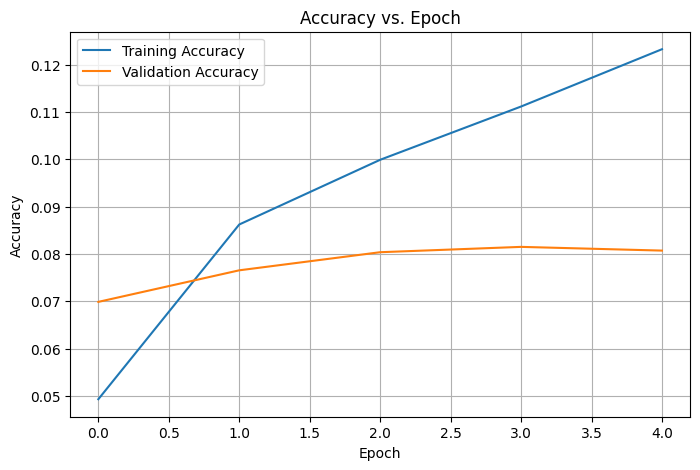

In [10]:
# Visualize accuracy versus epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


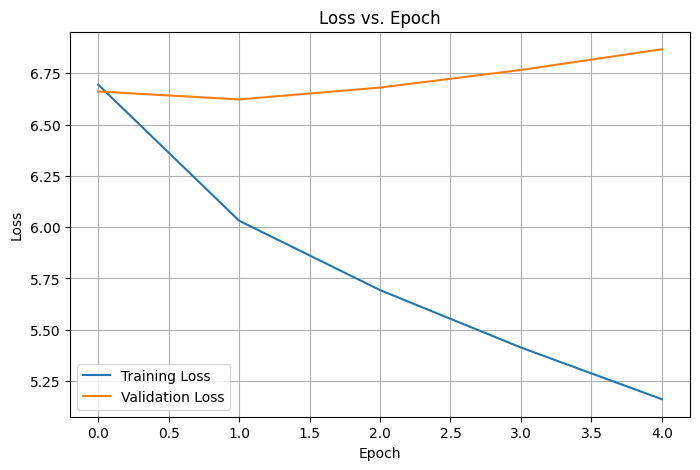

In [11]:
# Visualize loss versus epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Evaluate the model on the validation dataset
validation_loss, validation_accuracy = model.evaluate(
    X_val, y_val, batch_size=batch_size, verbose=0
)

print(f"Validation Loss: {validation_loss:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")


Validation Loss: 6.8672
Validation Accuracy: 0.0807


## Task D: Deep Learning Experiment Management


**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072  

In [13]:
# Reverse vocabulary for converting predicted indices into words
index_to_word = {index: word for word, index in tokenizer.word_index.items()}
index_to_word[0] = ""

def generate_text(seed_text, next_words=30, temperature=0.8):
    """Generate text by repeatedly predicting the next word."""
    generated = seed_text.lower()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated])[0]
        token_list = token_list[-sequence_length:]
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        predictions = model.predict(token_list, verbose=0)[0]

        # Temperature sampling
        predictions = np.asarray(predictions).astype("float64")
        predictions = np.log(predictions + 1e-8) / temperature
        probabilities = np.exp(predictions) / np.sum(np.exp(predictions))

        predicted_id = np.random.choice(len(probabilities), p=probabilities)
        predicted_word = index_to_word.get(predicted_id, "")

        if predicted_word == "":
            continue

        generated += " " + predicted_word

    return generated


In [14]:
# Generate multiple text samples using different seed inputs
seed_inputs = [
    "to be or",
    "the king",
    "my lord",
    "what is",
    "love is"
]

generated_samples = []

for seed in seed_inputs:
    sample = generate_text(seed, next_words=30, temperature=0.8)
    generated_samples.append({"Seed Input": seed, "Generated Text": sample})

samples_df = pd.DataFrame(generated_samples)
samples_df


,Seed Input,Generated Text
0,to be or,to be or by 't come by you your father froth o...
1,the king,the king richard iii and throw unto our mistre...
2,my lord,my lord upon that folly for my tongue i came t...
3,what is,what is a subtle wit a substitutes of death th...
4,love is,love is anointed husband and the other lost fi...


In [15]:
# Compare generated samples for coherence and contextual relevance
for row in generated_samples:
    print("=" * 80)
    print("Seed:", row["Seed Input"])
    print("Generated Text:", row["Generated Text"])


Seed: to be or
Generated Text: to be or by 't come by you your father froth o sir the brood citizens have you have all that do you know i am in thy kings and let him not
Seed: the king
Generated Text: the king richard iii and throw unto our mistress and most red i am the trumpeter to our business i'll draw to have't thee credit an hour virgilia and you to speak
Seed: my lord
Generated Text: my lord upon that folly for my tongue i came to confirm with him and call him hence for you for i can rather say the better but must have fought with
Seed: what is
Generated Text: what is a subtle wit a substitutes of death that i have you know my life catesby it is our very man not not polixenes sicinius what says what is too young
Seed: love is
Generated Text: love is anointed husband and the other lost first senator the provost he will not be heavier or by your grace northumberland john of gaunt i would i think in the cause
